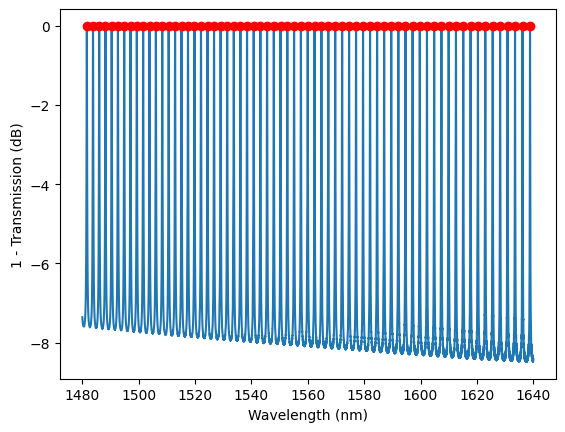

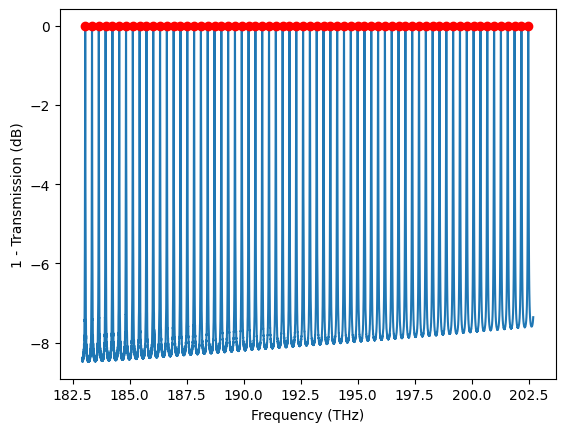

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# Load data
c = 3e8
data = np.loadtxt(
    r"D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing"
    r"\Data_RingMOD_BasicRing_pwsource_Amax0.00nm_M631-612_Nm16_LambdaRange1480-1640nm_Gap600nm_Tx.txt"
)

lambda_data = data[:, 0]
T_data = data[:, 1][::-1]  # flipud
Freq_data = c / (lambda_data * 1e-6)

# Smoothed 1-T and peak finding
InvT = uniform_filter1d(1 - T_data, size=10)
peaks_idx, properties = find_peaks(InvT, prominence=0.2, distance=50)
Freqs = Freq_data[peaks_idx]

# Figure 1: wavelength
fig1, ax1 = plt.subplots()
ax1.plot(lambda_data * 1e3, 10 * np.log10(InvT))
ax1.plot(lambda_data[peaks_idx] * 1e3, 10 * np.log10(InvT[peaks_idx]), 'ro')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('1 - Transmission (dB)')

# Figure 2: frequency
fig2, ax2 = plt.subplots()
ax2.plot(Freq_data * 1e-12, 10 * np.log10(InvT))
ax2.plot(Freqs * 1e-12, 10 * np.log10(InvT[peaks_idx]), 'ro')
ax2.set_xlabel('Frequency (THz)')
ax2.set_ylabel('1 - Transmission (dB)')

plt.show()